# 🧠 Face Recognition Pipeline: The "Loncat-Loncat" & Unseen Data Method
Ini adalah metode evaluasi standar **Penelitian Skripsi/Tugas Akhir**.

1. Video 15 detik (sekitar ±450 frame) dibentangkan.
2. Kita panen tepat **30 Foto** secara lompat-lompat / tersebar (bukan urut depan doang).
3. Ada keranjang **Foto Sisa** (ratusan foto yang tadi di-skip dan gak kepilih).
4. **Tahap Training AI:** Yang dipakai hanyalah 30 Foto (Sistem 80:20 Training & Ujian).
5. **Ujian Akhir Kelulusan:** Nah, foto "Sisa Lembuangan" yang 100% masih prawan dan sama sekali 
   belum pernah disentuh AI, kita gebrak jadikan soal "Ujian Final Unseen Data" di akhir sesi.

## Tahap 1: Persiapan Library

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from skimage.feature import local_binary_pattern
import seaborn as sns

# Pastikan folder kerja selalu di TUGAS AKHIR agar folder output muncul di tempat yang benar
os.chdir(r"C:\Users\Lenovo\TUGAS AKHIR")

print("✅ Library ter-load dengan baik!")
print(f"📂 Folder aktif saat ini: {os.getcwd()}")

✅ Library ter-load dengan baik!
📂 Folder aktif saat ini: C:\Users\Lenovo\TUGAS AKHIR


## Tahap 2: Menyedot Video 🎥 (Metode Loncat-Loncat)

In [2]:
VIDEO_DIR = r"face_videos"
kumpulan_30_gambar = {} 
kumpulan_sisa_gambar = {} 

print("🎬 Membaca full video enrollment dan memilah frame loncat-loncat...\n")

for user_id in sorted(os.listdir(VIDEO_DIR)):
    video_path = os.path.join(VIDEO_DIR, user_id, "enrollment.mp4")
    if not os.path.exists(video_path): continue
        
    cap = cv2.VideoCapture(video_path)
    # Cek durasi asli videonya ada berapa frame ratusan?
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Hitung Jarak Lompatan Matematis agar pas 30 (kalau video panjang bgt, jarak lompat jauh)
    target_ambil = 30
    skip_interval = max(1, total_frames // target_ambil)
    
    dikumpulkan_30 = []
    dikumpulkan_sisa = []
    
    frame_index = 0
    # Inisialisasi Detektor Wajah
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    
    wajah_valid_idx = 0
    
    # Tarik seluruh video sampai tamat
    while True: 
        ret, frame = cap.read()
        if not ret: break # Video tamat
            
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        wajah_terdeteksi = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50))
        
        if len(wajah_terdeteksi) == 0: 
            continue # Lewati jika tak ada wajah
            
        (x, y, w, h) = max(wajah_terdeteksi, key=lambda rect: rect[2]*rect[3])
        wajah_crop = gray[y:y+h, x:x+w]
        frame_kecil = cv2.resize(wajah_crop, (128, 128))
        
        # [BARU] Simpan SEMUA frame dulu ke folder "Full Ekstrak" sebelum dipisah
        folder_full = f"hasil_0_ekstrak_full/user_{user_id}"
        os.makedirs(folder_full, exist_ok=True)
        cv2.imwrite(f"{folder_full}/full_{frame_index+1}.jpg", frame_kecil)
        
        # Trik Loncat: Kalau indeksnya "kelipatan lompat", AMBIL buat kuota 30
        if wajah_valid_idx % skip_interval == 0 and len(dikumpulkan_30) < target_ambil:
            dikumpulkan_30.append(frame_kecil)
            
            # Simpan juga ke folder 30 pilihan
            simpan_folder = f"hasil_1_ekstrak_30/user_{user_id}"
            os.makedirs(simpan_folder, exist_ok=True)
            cv2.imwrite(f"{simpan_folder}/frame_utama_{len(dikumpulkan_30)}.jpg", frame_kecil)
        else:
            # Yang gak kepilih, masuk kardus sisa
            dikumpulkan_sisa.append(frame_kecil)
            
            folder_sisa = f"hasil_3_ekstrak_sisa_ujian/user_{user_id}"
            os.makedirs(folder_sisa, exist_ok=True)
            cv2.imwrite(f"{folder_sisa}/sisa_ujian_{len(dikumpulkan_sisa)}.jpg", frame_kecil)
            
        wajah_valid_idx += 1
        frame_index += 1
            
    cap.release()
    kumpulan_30_gambar[user_id] = dikumpulkan_30
    kumpulan_sisa_gambar[user_id] = dikumpulkan_sisa
    
    print(f"   👤 User {user_id}: Total di video = {total_frames} frame.")
    print(f"      ↳ Dicomot (Loncat tiap {skip_interval} frame) = {len(dikumpulkan_30)} Pilihan.")
    print(f"      ↳ Sisanya (Yg tidak dipilih sama sekali) = {len(dikumpulkan_sisa)} Ditaruh gudang.\n")

🎬 Membaca full video enrollment dan memilah frame loncat-loncat...

   👤 User 68: Total di video = 470 frame.
      ↳ Dicomot (Loncat tiap 15 frame) = 29 Pilihan.
      ↳ Sisanya (Yg tidak dipilih sama sekali) = 398 Ditaruh gudang.

   👤 User 69: Total di video = 477 frame.
      ↳ Dicomot (Loncat tiap 15 frame) = 30 Pilihan.
      ↳ Sisanya (Yg tidak dipilih sama sekali) = 447 Ditaruh gudang.

   👤 User 70: Total di video = 488 frame.
      ↳ Dicomot (Loncat tiap 16 frame) = 25 Pilihan.
      ↳ Sisanya (Yg tidak dipilih sama sekali) = 366 Ditaruh gudang.

   👤 User 71: Total di video = 474 frame.
      ↳ Dicomot (Loncat tiap 15 frame) = 30 Pilihan.
      ↳ Sisanya (Yg tidak dipilih sama sekali) = 420 Ditaruh gudang.



## Tahap 3: Fungsi Pola Jadi Angka (Algoritma LBP) 🔢
Kita menggunakan **`skimage`** (library profesional) agar LBP dihitung di C++ belakang layar.
Hasilnya ribuan kali lebih cepat dibanding loop Python manual!

In [3]:
from skimage.feature import local_binary_pattern

def ubah_wajah_jadi_angka_lbp(gambar):
    # 1. CLAHE DIHIDUPKAN (Pemerataan cahaya untuk menajamkan kontras fitur wajah)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gambar_jelas = clahe.apply(gambar)
    
    # 2. LBP via skimage (R=1, 8 titik tetangga — cepat & bersih)
    pola_lbp = local_binary_pattern(gambar_jelas, P=8, R=1, method='uniform')
    pola_lbp = pola_lbp.astype(np.uint8)
    
    # 3. Jadikan Histogram Global (Langsung dihitung sewajah penuh)
    histogram, _ = np.histogram(pola_lbp, bins=256, range=(0, 256), density=True)
    
    return histogram, gambar_jelas, pola_lbp

print("✅ Fungsi LBP (skimage) siap — jauh lebih cepat dari loop manual!")

✅ Fungsi LBP (skimage) siap — jauh lebih cepat dari loop manual!


## Tahap 4: Merubah Gambar Pilihan & Sisa Menjadi Matriks LBP 🔄

⚙️ Mengolah gambar menjadi LBP...

Sukses!
Data Set 30 Pilihan : 114 Matriks LBP
Data Set Sisa Buangan: 1631 Matriks LBP

🖼️ CONTOH HASIL PROSES LBP (1 Gambar per Parameter User):


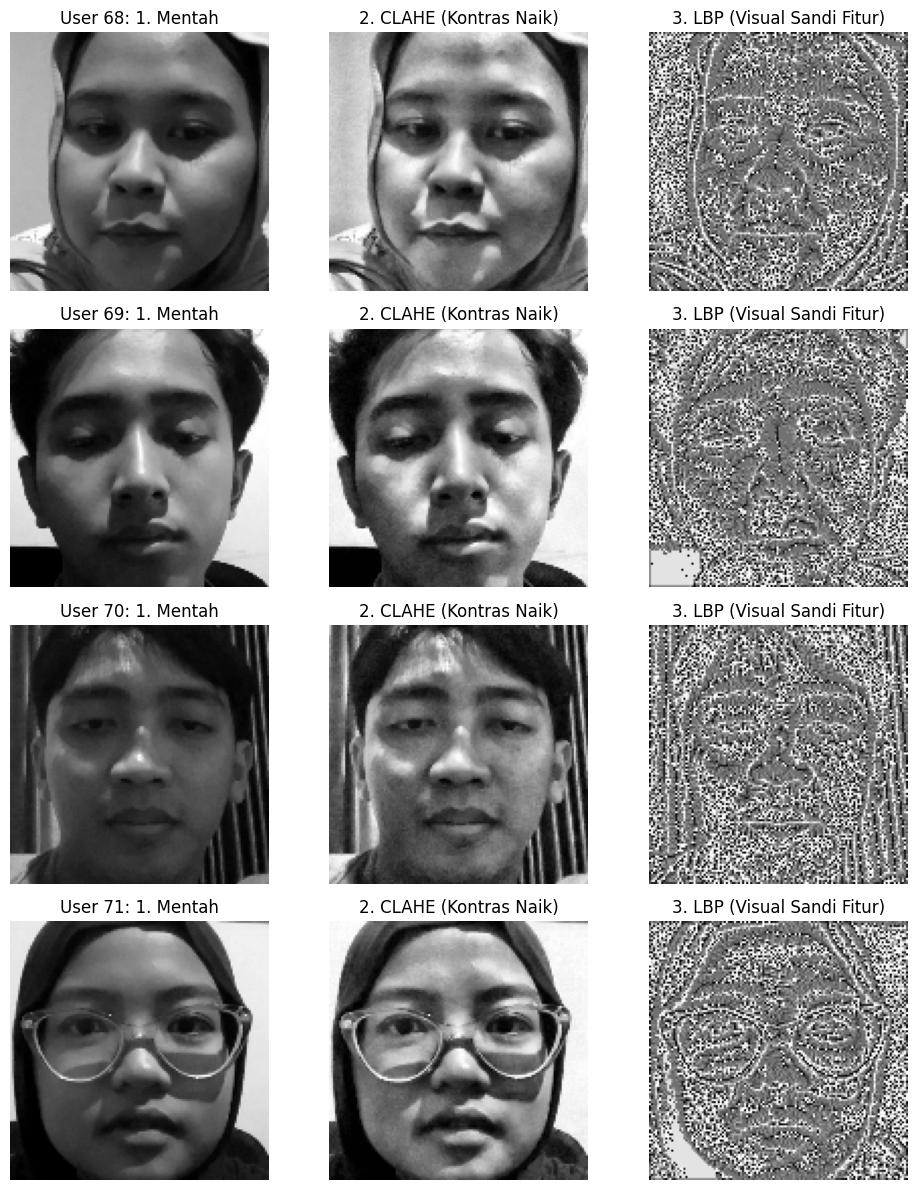

In [4]:
X_30 = [] 
y_30 = []
gambar_30 = []  # Simpan juga foto aslinya agar bisa dipisah nanti

X_sisa = []
y_sisa = []
contoh_visual = [] # Untuk menampilkan ke layar (1 per user)

print("⚙️ Mengolah gambar menjadi LBP...")

# Memproses data 30 Pilihan
for user_id, daftar_foto in kumpulan_30_gambar.items():
    counter = 1
    pertama = True
    for foto in daftar_foto:
        fitur_angka, efek_clahe, efek_lbp = ubah_wajah_jadi_angka_lbp(foto)       
        
        # Ambil sampel 1 foto untuk dipajang di layar
        if pertama:
            contoh_visual.append((user_id, foto, efek_clahe, efek_lbp))
            pertama = False
            
        # Simpan LBP ke folder bukti laporan
        folder_lbp = f"hasil_2_lbp_30/user_{user_id}"
        os.makedirs(folder_lbp, exist_ok=True)
        cv2.imwrite(f"{folder_lbp}/lbp_pilihan_{counter}.jpg", efek_lbp)
        counter += 1
        
        X_30.append(fitur_angka)
        y_30.append(user_id)
        gambar_30.append((user_id, foto))  # Simpan foto aslinya juga!

# Memproses data Buangan / Sisa
for user_id, daftar_foto in kumpulan_sisa_gambar.items():
    for foto in daftar_foto:
        fitur_angka, _, _ = ubah_wajah_jadi_angka_lbp(foto)
        X_sisa.append(fitur_angka)
        y_sisa.append(user_id)

# Convert jadi Numpy
X_30_numpy = np.array(X_30)
y_30_numpy = np.array(y_30)

X_sisa_numpy = np.array(X_sisa)
y_sisa_numpy = np.array(y_sisa)

print("\nSukses!")
print(f"Data Set 30 Pilihan : {len(X_30_numpy)} Matriks LBP")
print(f"Data Set Sisa Buangan: {len(X_sisa_numpy)} Matriks LBP")

# ── VISUALISASI PROSES EKTRAKSI ──────────────────────────────────────
print("\n🖼️ CONTOH HASIL PROSES LBP (1 Gambar per Parameter User):")
fig, axes = plt.subplots(len(contoh_visual), 3, figsize=(10, 3 * len(contoh_visual)))

# Handle jika user cuma 1 (supaya array 2D aman)
if len(contoh_visual) == 1: 
    axes = [axes]

for i, (uid, g_asli, g_clahe, g_lbp) in enumerate(contoh_visual):
    axes[i][0].imshow(g_asli, cmap='gray')
    axes[i][0].set_title(f"User {uid}: 1. Mentah")
    axes[i][0].axis('off')
    
    axes[i][1].imshow(g_clahe, cmap='gray')
    axes[i][1].set_title(f"2. CLAHE (Kontras Naik)")
    axes[i][1].axis('off')
    
    axes[i][2].imshow(g_lbp, cmap='gray')
    axes[i][2].set_title(f"3. LBP (Visual Sandi Fitur)")
    axes[i][2].axis('off')

plt.tight_layout()
plt.show()

## Tahap 5: Training AI (Memakai Data Set 30 Pilihan Saja 80:20) 🎓

In [5]:
# Pembagian CHRONOLOGICAL (Berdasarkan Waktu Rekaman)
# Video dibagi lurus: 80% detik awal untuk Training, 20% detik terakhir untuk Testing
# Secara otomatis mencegah kebocoran data karena berdekatan waktu

X_train, X_test, y_train, y_test, idx_test = [], [], [], [], []
user_unik = np.unique(y_30_numpy)

for usr in user_unik:
    # Cari indeks urutan foto milik user ini (Otomatis urut waktu karena dari Tahap 2 tidak diacak)
    idx_usr = np.where(y_30_numpy == usr)[0]
    
    # Titik potong 80% video
    batas_waktu = int(len(idx_usr) * 0.8)
    
    # 80% waktu awal -> Training
    idx_train_usr = idx_usr[:batas_waktu]
    for i in idx_train_usr:
        X_train.append(X_30_numpy[i])
        y_train.append(y_30_numpy[i])
        
    # 20% waktu sisa -> Testing
    idx_test_usr = idx_usr[batas_waktu:]
    for i in idx_test_usr:
        X_test.append(X_30_numpy[i])
        y_test.append(y_30_numpy[i])
        idx_test.append(i)

# Kembalikan ke format array Numpy standar Mesin
X_train, X_test = np.array(X_train), np.array(X_test)
y_train, y_test = np.array(y_train), np.array(y_test)

# FITUR SCALER DIHIDUPKAN KEMBALI
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_sisa_scaled = scaler.transform(X_sisa_numpy)

# [BARU] Simpan foto-foto yang jatuh ke Testing (20%) ke folder tersendiri
print("💾 Menyimpan foto Internal Testing (20%) ke folder...")
for urutan, idx in enumerate(idx_test):
    user_id_foto, foto_asli = gambar_30[idx]
    folder_test = f"hasil_4_foto_internal_test/user_{user_id_foto}"
    os.makedirs(folder_test, exist_ok=True)
    cv2.imwrite(f"{folder_test}/test_{urutan+1}.jpg", foto_asli)

print(f"🧠 AI Mulai Menghafal {len(X_train)} Lembar (80% Pelajaran)...")
# Algoritma SVM Kembali Cerdas (Dengan RBF)
ai_model = SVC(kernel='rbf', C=5, verbose=True)
ai_model.fit(X_train_scaled, y_train)

print(f"✅ Selesai Menghafal!")

# Simpan model ke file agar bisa dipakai kapan saja tanpa training ulang
import joblib
joblib.dump(ai_model, "model_wajah.pkl")
joblib.dump(scaler, "scaler_wajah.pkl") 
print("💾 Model disimpan ke: model_wajah.pkl & scaler_wajah.pkl")

💾 Menyimpan foto Internal Testing (20%) ke folder...
🧠 AI Mulai Menghafal 91 Lembar (80% Pelajaran)...
[LibSVM]✅ Selesai Menghafal!
💾 Model disimpan ke: model_wajah.pkl & scaler_wajah.pkl


## 📸 Tahap 6A: Check Akurasi dari 20% Data Tes Rutin 📝
Ini akurasi standar. Apakah dia hafal dari 20% sisa fotonya tadi? (Seharusnya menembus nyaris 100%)

🎯 AKURASI TES INTERNAL 20% (STANDAR) : 78.26 %


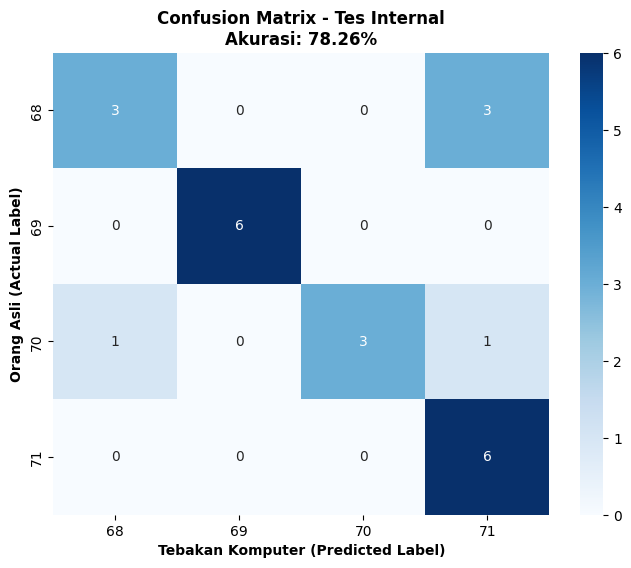

In [6]:
jawaban_tes_internal = ai_model.predict(X_test_scaled)
akurasi_internal = accuracy_score(y_test, jawaban_tes_internal)

print("="*45)
print(f"🎯 AKURASI TES INTERNAL 20% (STANDAR) : {akurasi_internal * 100:.2f} %")
print("="*45)

# ── VISUALISASI CONFUSION MATRIX ────────────────────────────
cm = confusion_matrix(y_test, jawaban_tes_internal)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title(f"Confusion Matrix - Tes Internal\nAkurasi: {akurasi_internal*100:.2f}%", fontweight='bold')
plt.xlabel("Tebakan Komputer (Predicted Label)", fontweight='bold')
plt.ylabel("Orang Asli (Actual Label)", fontweight='bold')
plt.show()

## 🎥 Tahap 6B: UJI MODEL DENGAN VIDEO TES SENDIRI
Masukkan video apapun ke folder `video_test/` lalu jalankan sel ini.
Sistem akan mengekstrak frame dari video tersebut, menjalankan LBP,
dan menebak siapa orang di dalamnya pakai **Majority Vote** (tebakan terbanyak menang).

🎬 Ditemukan 4 video di folder 'video_test/'



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13696\2517343255.py:92: UserWarning: Glyph 128249 (\N{VIDEO CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128249 (\N{VIDEO CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


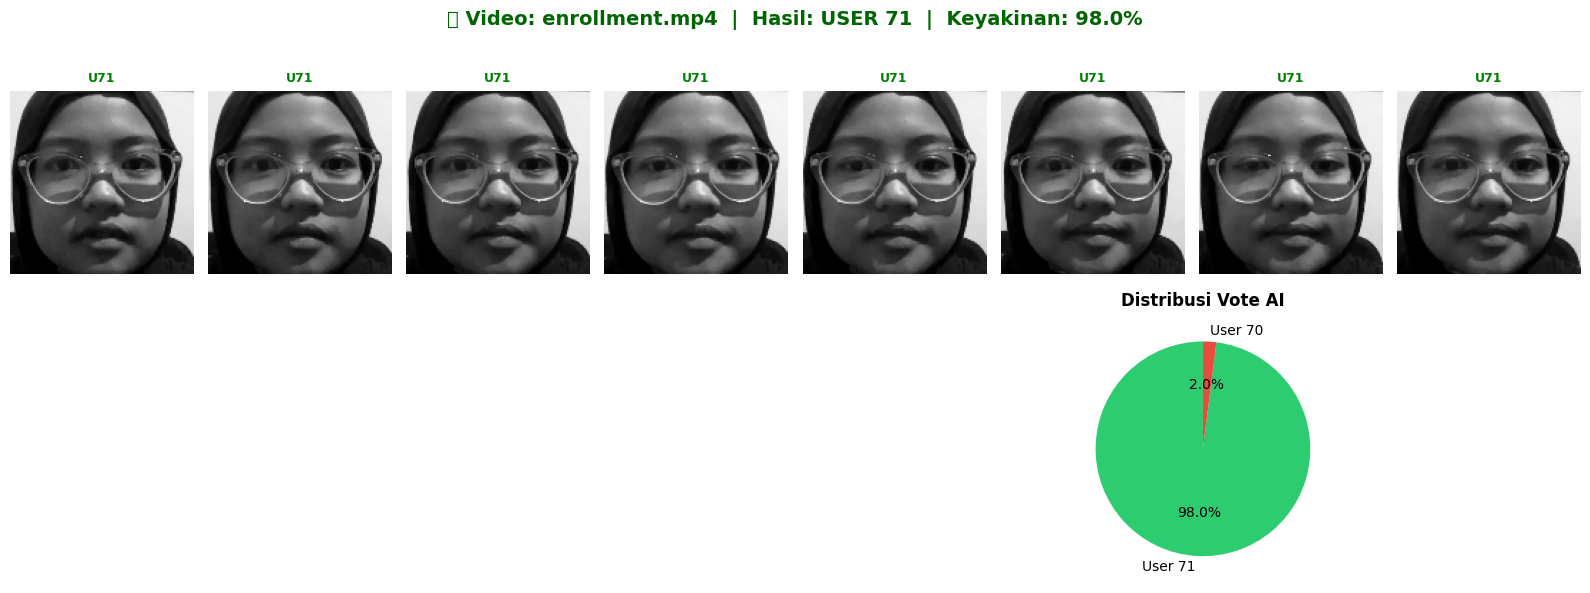

✅ Dikenali sebagai → USER 71  (98.0% keyakinan)



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13696\2517343255.py:92: UserWarning: Glyph 128249 (\N{VIDEO CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128249 (\N{VIDEO CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


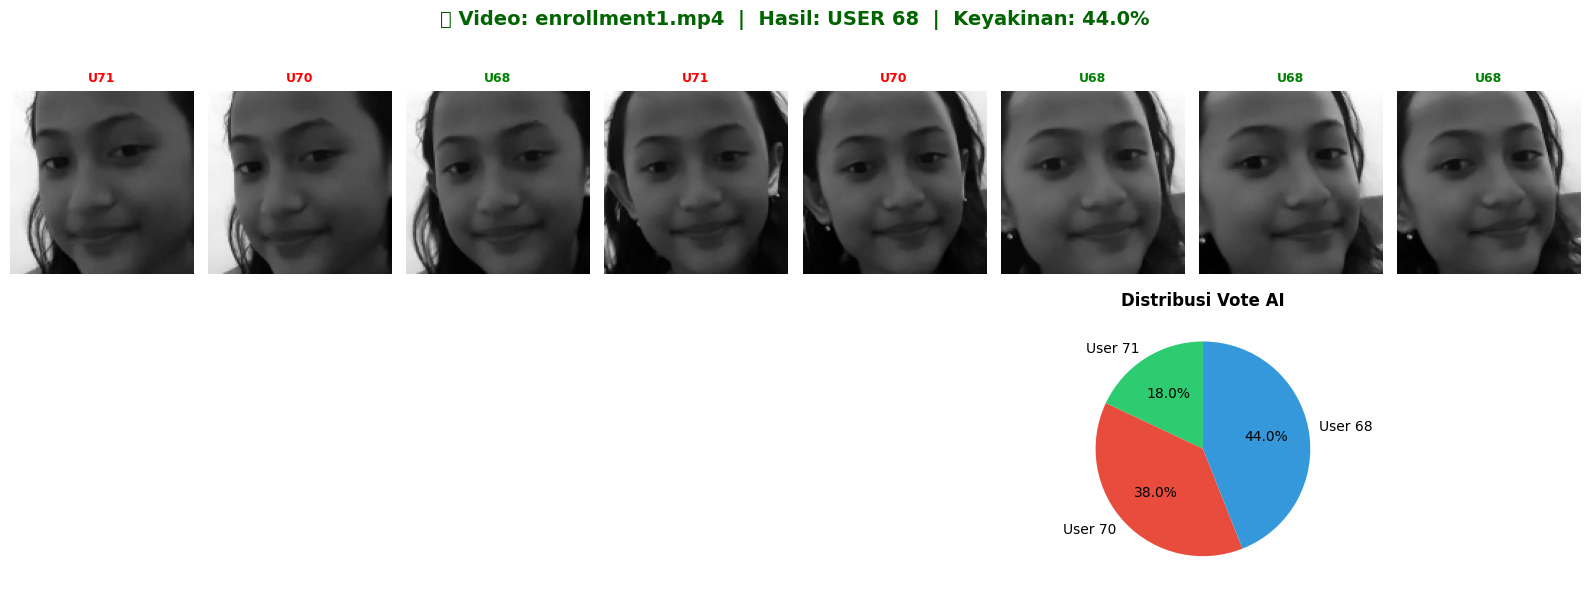

✅ Dikenali sebagai → USER 68  (44.0% keyakinan)



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13696\2517343255.py:92: UserWarning: Glyph 128249 (\N{VIDEO CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128249 (\N{VIDEO CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


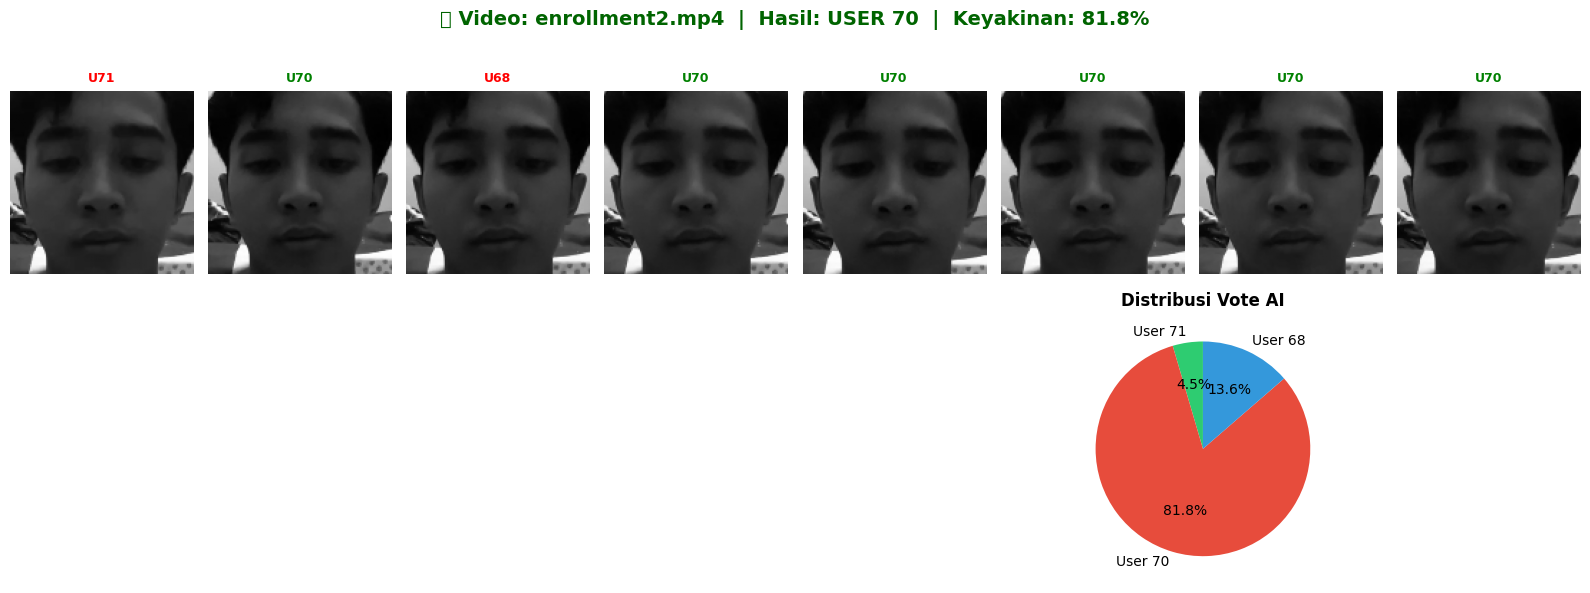

✅ Dikenali sebagai → USER 70  (81.8% keyakinan)



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13696\2517343255.py:92: UserWarning: Glyph 128249 (\N{VIDEO CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128249 (\N{VIDEO CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


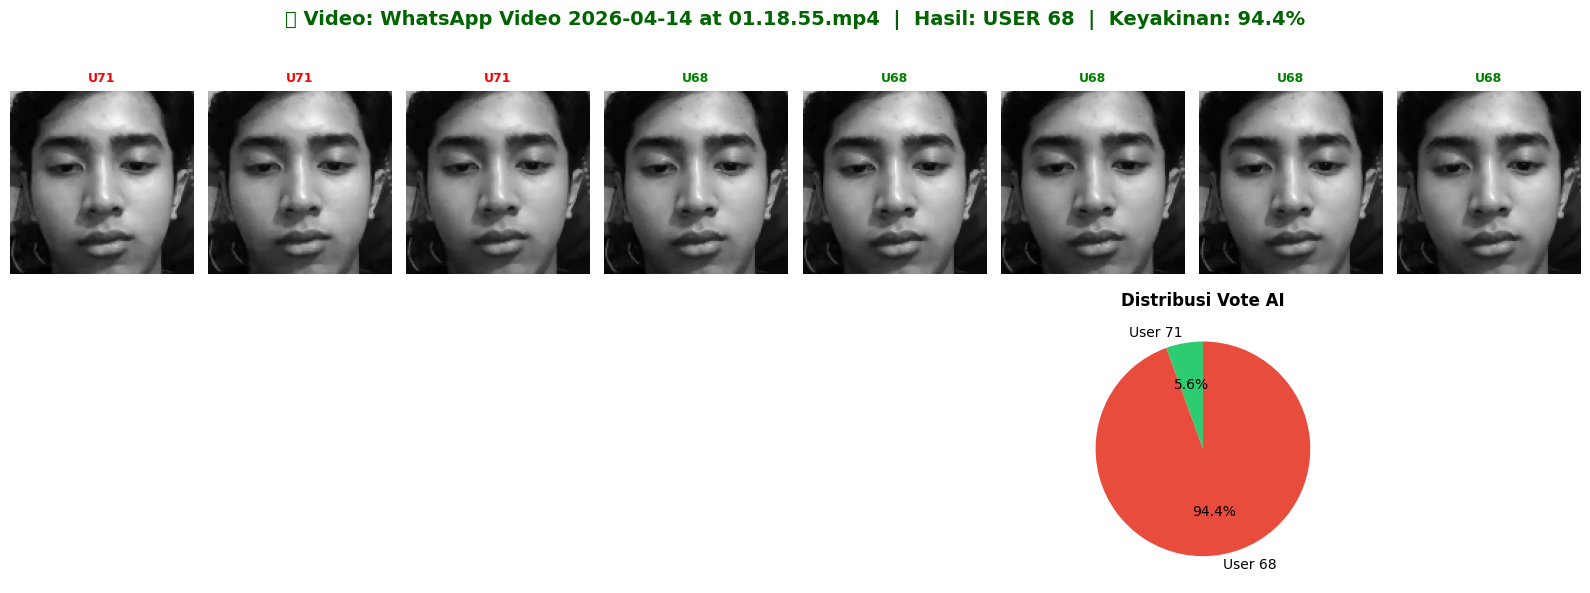

✅ Dikenali sebagai → USER 68  (94.4% keyakinan)



In [7]:
VIDEO_TEST_DIR = "video_test"

video_files = [
    f for f in os.listdir(VIDEO_TEST_DIR) 
    if f.endswith(('.mp4', '.avi', '.mov', '.mkv'))
]

if len(video_files) == 0:
    print("⚠️  Folder 'video_test/' masih kosong!")
    print("💡 Masukkan file video (.mp4) ke folder tersebut lalu jalankan sel ini lagi.")
else:
    print(f"🎬 Ditemukan {len(video_files)} video di folder 'video_test/'\n")
    
    for nama_video in video_files:
        path_video = os.path.join(VIDEO_TEST_DIR, nama_video)
        cap = cv2.VideoCapture(path_video)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        tebakan_per_frame = []
        contoh_frame_gambar = []   # Simpan beberapa gambar untuk divisualisasikan
        contoh_frame_tebakan = []  # Tebakan per frame untuk label gambarnya
        frame_idx = 0
        skip = max(1, total_frames // 50)  # Ambil maksimal 50 frame dari video tes
        
        face_cascade_6b = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
        
        while True:
            ret, frame = cap.read()
            if not ret: break
            
            if frame_idx % skip == 0:
                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                # Video Uji Jaring juga harus memotong kotakan wajah persis Tahap 2
                wajah_terdeteksi = face_cascade_6b.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
                
                if len(wajah_terdeteksi) > 0:
                    (x, y, w, h) = max(wajah_terdeteksi, key=lambda rect: rect[2]*rect[3])
                    wajah_crop = gray[y:y+h, x:x+w]
                    frame_kecil = cv2.resize(wajah_crop, (128, 128))
                    
                    # Proses LBP + Prediksi
                    fitur, _, _ = ubah_wajah_jadi_angka_lbp(frame_kecil)
                    
                    # SCALER DIHIDUPKAN KEMBALI
                    fitur_scaled = scaler.transform([fitur])
                    
                    tebakan = ai_model.predict(fitur_scaled)[0]
                    tebakan_per_frame.append(tebakan)
                    
                    # Kumpulkan max 8 gambar sampel untuk dipajang (Sekarang wajah sudah tercrop!)
                    if len(contoh_frame_gambar) < 8:
                        contoh_frame_gambar.append(frame_kecil)
                        contoh_frame_tebakan.append(tebakan)
                
            frame_idx += 1
        cap.release()
        
        if len(tebakan_per_frame) == 0:
            print(f"❌ {nama_video}: Tidak ada frame yang berhasil diproses.")
            continue
        
        # Majority Vote
        from collections import Counter
        hitungan = Counter(tebakan_per_frame)
        pemenang = hitungan.most_common(1)[0][0]
        jumlah_menang = hitungan.most_common(1)[0][1]
        persen_yakin = (jumlah_menang / len(tebakan_per_frame)) * 100
        
        # ── VISUALISASI ──────────────────────────────────────
        n_gambar = len(contoh_frame_gambar)
        fig = plt.figure(figsize=(16, 6))
        fig.suptitle(f"📹 Video: {nama_video}  |  Hasil: USER {pemenang}  |  Keyakinan: {persen_yakin:.1f}%",
                     fontsize=14, fontweight='bold', color='darkgreen')
        
        # Kiri: 8 sampel frame dengan label tebakan per frame
        for i, (img, tebak) in enumerate(zip(contoh_frame_gambar, contoh_frame_tebakan)):
            ax = fig.add_subplot(2, 8, i + 1)
            ax.imshow(img, cmap='gray')
            warna = 'green' if tebak == pemenang else 'red'
            ax.set_title(f"U{tebak}", fontsize=9, color=warna, fontweight='bold')
            ax.axis('off')
        
        # Kanan bawah: Pie chart vote
        ax_pie = fig.add_subplot(2, 2, 4)
        labels = [f"User {k}" for k in hitungan.keys()]
        sizes = list(hitungan.values())
        colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']
        ax_pie.pie(sizes, labels=labels, colors=colors[:len(sizes)],
                   autopct='%1.1f%%', startangle=90)
        ax_pie.set_title("Distribusi Vote AI", fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        print(f"✅ Dikenali sebagai → USER {pemenang}  ({persen_yakin:.1f}% keyakinan)\n")

## 💥 Tahap 6C: UJI AKURASI "GUDANG SISA DATA" (MASSIVE UNSEEN TEST)
Mesin akan diuji pada **seluruh ratusan frame video yang disisakan / dibuang di Tahap 2**.
Ini adalah pembuktian ultimasi karena frame rongsokan ini murni belum pernah dilirik sekilas pun oleh AI.

🔥 AKURASI DATA SISA BANYAK (1631 FRAME TERCAKUP) : 96.26 %


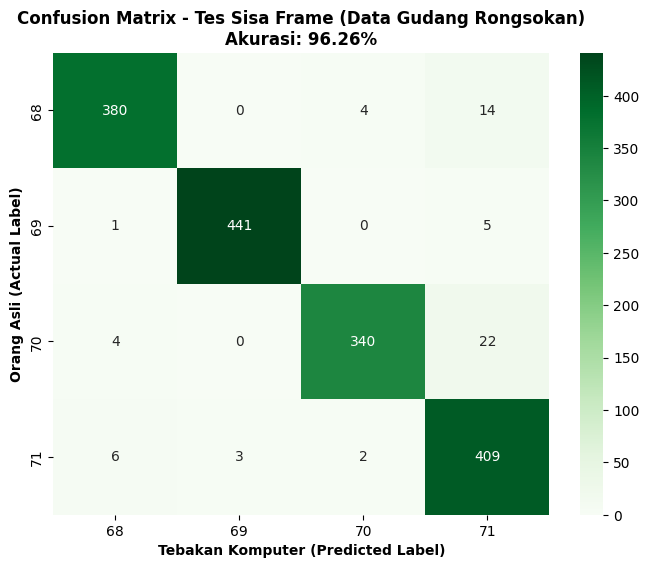

In [8]:
if len(X_sisa_scaled) > 0:
    jawaban_sisa = ai_model.predict(X_sisa_scaled)
    akurasi_sisa = accuracy_score(y_sisa_numpy, jawaban_sisa)

    print("="*45)
    print(f"🔥 AKURASI DATA SISA BANYAK ({len(X_sisa_scaled)} FRAME TERCAKUP) : {akurasi_sisa * 100:.2f} %")
    print("="*45)

    # ── VISUALISASI CONFUSION MATRIX 6C ────────────────────────────
    cm_6c = confusion_matrix(y_sisa_numpy, jawaban_sisa)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_6c, annot=True, fmt="d", cmap="Greens", 
                xticklabels=np.unique(y_sisa_numpy), yticklabels=np.unique(y_sisa_numpy))
    plt.title(f"Confusion Matrix - Tes Sisa Frame (Data Gudang Rongsokan)\nAkurasi: {akurasi_sisa*100:.2f}%", fontweight='bold')
    plt.xlabel("Tebakan Komputer (Predicted Label)", fontweight='bold')
    plt.ylabel("Orang Asli (Actual Label)", fontweight='bold')
    plt.show()
else:
    print("⚠️ Tidak ada data gudang sisa (Semua frame video tepakai tanpa sisa).")